# InternVL3 Document-Aware Batch Processing


## 1. Imports

In [1]:
# Core imports
import os
import sys
import time
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from rich import print as rprint
from rich.console import Console

warnings.filterwarnings('ignore')
console = Console()

# Set project root
project_root = Path.cwd()
sys.path.insert(0, str(project_root))

# Import only what we need - NO BatchDocumentProcessor!
from common.batch_analytics import BatchAnalytics
from common.batch_reporting import BatchReporter
from common.batch_visualizations import BatchVisualizer
from common.evaluation_metrics import load_ground_truth
from common.extraction_parser import discover_images, parse_extraction_response
from common.unified_schema import DocumentTypeFieldSchema
from models.document_aware_internvl3_processor import DocumentAwareInternVL3Processor

# ENHANCED: Import accuracy restoration modules
from common.standalone_evaluator import StandaloneEvaluator
from common.standalone_detection import StandaloneDocumentDetector
from common.dynamic_field_processor import DynamicFieldProcessor

print("✅ Enhanced imports completed successfully")
print(f"📁 Project root: {project_root}")
print("🚀 Enhanced modules: StandaloneEvaluator, StandaloneDocumentDetector, DynamicFieldProcessor")

✅ Enhanced imports completed successfully
📁 Project root: /home/jovyan/nfs_share/tod/LMM_POC
🚀 Enhanced modules: StandaloneEvaluator, StandaloneDocumentDetector, DynamicFieldProcessor


## 2. Configuration

In [2]:
# Configuration - Simple and clean
CONFIG = {
    # Model settings
    'MODEL_PATH': "/home/jovyan/nfs_share/models/InternVL3-8B",  # Jupyter environment path
    
    # Batch settings
    'DATA_DIR': 'evaluation_data',
    'GROUND_TRUTH': 'evaluation_data/ground_truth.csv',
    'MAX_IMAGES': None,  # None for all, or set limit
    'DOCUMENT_TYPES': None,  # None for all, or ['invoice', 'receipt']
    
    # Output settings
    'OUTPUT_BASE': os.getenv('OUTPUT_DIR', 'output'),
    
    # Verbosity control (similar to Llama notebook)
    'VERBOSE': False,  # Control detailed output vs minimal output
    'SHOW_PROMPTS': False,  # Show document detection prompts (only when VERBOSE=True)
    
    # V100 optimization settings
    'USE_QUANTIZATION': True,
    'DEVICE_MAP': 'auto',
    'MAX_NEW_TOKENS': 4000,
    'TORCH_DTYPE': 'bfloat16',
    'LOW_CPU_MEM_USAGE': True
}

# Verbosity Examples:
# VERBOSE=False: Minimal output with progress bar, one line per image
#   ✅ image_001.png: receipt, Accuracy: 78.6%, Time: 21.4s
#   ⚠️ image_002.png: invoice, Accuracy: 65.2%, Time: 18.3s
#
# VERBOSE=True: Detailed processing steps, field analysis, and timing
#   📄 Processing 1/9: image_001.png
#   🔍 Step 1: Enhanced document type detection...
#   📋 Detected: receipt (confidence: high)
#   🔄 Step 2: Updating processor with document-specific fields...
#   ⚡ Step 3: Enhanced field extraction...
#   📊 Step 4: Enhanced evaluation with fuzzy matching...
#   ✅ Success 🚀⚡ - Type: receipt, Found: 14, Matched: 12, Accuracy: 78.6%, Time: 21.35s
#   📋 Enhanced field analysis with extracted values (first 3 fields):
#      ❌ DOCUMENT_TYPE: MISS (mismatch)
#      Extracted: 'receipt' | Expected: 'invoice'
#
# SHOW_PROMPTS=True (requires VERBOSE=True): Also displays the detection prompt used

# CRITICAL: Keep the working prompt configuration that fixed accuracy!
PROMPT_CONFIG = {
    'detection_file': 'prompts/document_type_detection.yaml',
    'detection_key': 'detection',
    'extraction_files': {
        'INVOICE': 'prompts/internvl3_invoice_extraction.yaml',
        'RECEIPT': 'prompts/internvl3_receipt_extraction.yaml',
        'BANK_STATEMENT': 'prompts/internvl3_bank_statement_extraction.yaml'
    },
    'extraction_keys': {
        'INVOICE': 'standard',
        'RECEIPT': 'standard', 
        'BANK_STATEMENT': 'flat'  # Use flat for bank statements
    }
}

print("✅ Configuration loaded")
print(f"🎯 Model: {CONFIG['MODEL_PATH']}")
print(f"📊 Prompt config: InternVL3-specific prompts with format enforcement")
print(f"🔊 Verbose mode: {'ON - Detailed output' if CONFIG['VERBOSE'] else 'OFF - Minimal output'}")
print(f"📝 Show prompts: {'ON' if CONFIG['SHOW_PROMPTS'] else 'OFF'} (requires VERBOSE=True)")

✅ Configuration loaded
🎯 Model: /home/jovyan/nfs_share/models/InternVL3-8B
📊 Prompt config: InternVL3-specific prompts with format enforcement
🔊 Verbose mode: OFF - Minimal output
📝 Show prompts: OFF (requires VERBOSE=True)


## 3. Output Directory Setup

In [3]:
# Setup output directories
OUTPUT_BASE = Path(CONFIG['OUTPUT_BASE'])
if not OUTPUT_BASE.is_absolute():
    OUTPUT_BASE = Path.cwd() / OUTPUT_BASE

BATCH_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

OUTPUT_DIRS = {
    'base': OUTPUT_BASE,
    'batch': OUTPUT_BASE / 'batch_results',
    'csv': OUTPUT_BASE / 'csv',
    'visualizations': OUTPUT_BASE / 'visualizations',
    'reports': OUTPUT_BASE / 'reports'
}

for dir_path in OUTPUT_DIRS.values():
    dir_path.mkdir(parents=True, exist_ok=True)

print(f"✅ Output directories created")
print(f"📁 Base: {OUTPUT_BASE}")
print(f"⏰ Timestamp: {BATCH_TIMESTAMP}")

✅ Output directories created
📁 Base: /home/jovyan/nfs_share/tod/LMM_POC/output
⏰ Timestamp: 20250915_211539


## 4. Initialize Schema

In [4]:
# Initialize document schema
schema_loader = DocumentTypeFieldSchema(model="internvl3")
print(f"✅ Schema loaded with {schema_loader.total_fields} total fields")

# We'll initialize the processor in the batch processing loop
print("✅ Schema ready for document-aware processing")
print("🎯 Processor will be initialized during batch processing (lazy loading)")

✅ Schema loaded with 19 total fields
✅ Schema ready for document-aware processing
🎯 Processor will be initialized during batch processing (lazy loading)


# 5.Load InternVL3 model

In [5]:
# Load InternVL3 model early with intelligent multi-GPU optimization
from common.internvl3_model_loader import load_internvl3_model

rprint("[bold blue]🚀 Loading InternVL3 model with intelligent multi-GPU optimization...[/bold blue]")
rprint("[cyan]Features: Smart quantization, memory management, multi-V100 support[/cyan]")

# Load model using intelligent quantization (auto-detects if 4x V100 memory is sufficient)
internvl3_model, internvl3_tokenizer = load_internvl3_model(
    model_path=CONFIG['MODEL_PATH'],
    use_quantization=CONFIG['USE_QUANTIZATION'],  # Will be overridden based on available memory
    device_map=CONFIG['DEVICE_MAP'],
    max_new_tokens=CONFIG['MAX_NEW_TOKENS'],
    torch_dtype=CONFIG['TORCH_DTYPE'],
    low_cpu_mem_usage=CONFIG['LOW_CPU_MEM_USAGE'],
    verbose=CONFIG['VERBOSE']
)

rprint("[bold green]✅ InternVL3 model ready for enhanced batch processing[/bold green]")
rprint("[cyan]🔧 Multi-GPU optimizations: Intelligent quantization, memory distribution[/cyan]")

# Store for use in processor initialization
MODEL_COMPONENTS = {
    'model': internvl3_model,
    'tokenizer': internvl3_tokenizer,
    'early_loaded': True,
    'optimization_features': ['intelligent_quantization', 'multi_gpu_memory', 'v100_optimized']
}

# ENHANCED: Initialize accuracy restoration components
rprint("[bold blue]🚀 Initializing Enhanced Accuracy Components[/bold blue]")

# Initialize standalone evaluator (enhanced accuracy scoring)
evaluator = StandaloneEvaluator()
rprint("[green]✅ StandaloneEvaluator initialized - fuzzy matching, currency normalization[/green]")

# Initialize document detector (YAML-first detection)
detector = StandaloneDocumentDetector()
rprint("[green]✅ StandaloneDocumentDetector initialized - YAML-first approach[/green]")

# Initialize dynamic field processor (document-aware field lists)
field_processor = DynamicFieldProcessor()
rprint("[green]✅ DynamicFieldProcessor initialized - document-specific field lists[/green]")

🚀 Loading InternVL3 model with intelligent multi-GPU optimization...

Features: Smart quantization, memory management, multi-V100 support

FlashAttention2 is not installed.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

✅ InternVL3 model ready for enhanced batch processing

🔧 Multi-GPU optimizations: Intelligent quantization, memory distribution

🚀 Initializing Enhanced Accuracy Components

✅ StandaloneEvaluator initialized - fuzzy matching, currency normalization

✅ StandaloneDocumentDetector initialized - YAML-first approach

✅ DynamicFieldProcessor initialized - document-specific field lists

## 6. Enhanced Batch Processing

In [6]:
# Discover and filter images
all_images = discover_images(CONFIG['DATA_DIR'])
ground_truth = load_ground_truth(CONFIG['GROUND_TRUTH'], verbose=CONFIG['VERBOSE'])

# Apply filters
if CONFIG['DOCUMENT_TYPES']:
    filtered = []
    for img in all_images:
        img_name = Path(img).name
        if img_name in ground_truth:
            doc_type = ground_truth[img_name].get('DOCUMENT_TYPE', '').lower()
            if any(dt.lower() in doc_type for dt in CONFIG['DOCUMENT_TYPES']):
                filtered.append(img)
    all_images = filtered

if CONFIG['MAX_IMAGES']:
    all_images = all_images[:CONFIG['MAX_IMAGES']]

rprint(f"[bold green]Ready to process {len(all_images)} images[/bold green]")
for i, img in enumerate(all_images[:5], 1):
    print(f"  {i}. {Path(img).name}")
if len(all_images) > 5:
    print(f"  ... and {len(all_images) - 5} more")

Ready to process 9 images

  1. image_001.png
  2. image_002.png
  3. image_003.png
  4. image_004.png
  5. image_005.png
  ... and 4 more


# 7. Enhanced Modular Batch Processing 🚀



In [7]:
# ENHANCED: Modular batch processing using InternVL3EnhancedBatchProcessor
from common.internvl3_enhanced_batch_processor import InternVL3EnhancedBatchProcessor

# Initialize enhanced batch processor with all components
batch_processor = InternVL3EnhancedBatchProcessor(
    config=CONFIG,
    prompt_config=PROMPT_CONFIG,
    model_components=MODEL_COMPONENTS,
    schema_loader=schema_loader,
    evaluator=evaluator,
    detector=detector,
    field_processor=field_processor
)

# Process batch with clean interface - all complexity is now modularized
batch_results, processing_times, document_types_found = batch_processor.process_batch(
    images=all_images,
    verbose=CONFIG["VERBOSE"],
    ground_truth=ground_truth
)

🚀 Starting ENHANCED batch processing with advanced monitoring...

Features: YAML-first detection, dynamic fields, enhanced evaluation, memory monitoring, performance profiling

✅ Using early-loaded InternVL3 model with V100-compatible optimizations

🔧 CUDA memory allocation configured: max_split_size_mb:64
💡 Using 64MB memory blocks to reduce fragmentation
📊 Initial CUDA state: Allocated=6.79GB, Reserved=6.79GB
🤖 Auto-detected batch size: 2 (GPU Memory: 132.9GB, Model: internvl3-8b)
🎯 Generation config: max_new_tokens=950, do_sample=False (greedy decoding)


✅ Processor initialized with early-loaded model

...

❌ image_009.png: bank_statement, Accuracy: 37.1%, Time: 14.1s

🚀 Enhanced processing complete!

✅ Processed: 9 images

⏱️ Average time: 12.33s

📋 Document types found: {'receipt': 3, 'bank_statement': 3, 'invoice': 3}

# 8.Create analytics

In [8]:
# Create analytics using standard BatchAnalytics
analytics = BatchAnalytics(batch_results, processing_times)

# Generate and save DataFrames
saved_files, df_results, df_summary, df_doctype_stats, df_field_stats = analytics.save_all_dataframes(
    OUTPUT_DIRS['csv'], BATCH_TIMESTAMP, verbose=CONFIG['VERBOSE']
)

# Display key results
rprint("\n[bold blue]📊 Results Summary[/bold blue]")
display(df_summary)

if not df_doctype_stats.empty:
    rprint("\n[bold blue]📋 Document Type Performance[/bold blue]")
    display(df_doctype_stats)

📊 Results Summary

,Value
Total Images,9.000000
Successful Extractions,9.000000
Failed Extractions,0.000000
Average Accuracy (%),73.174603
Median Accuracy (%),78.571429
Min Accuracy (%),37.142857
Max Accuracy (%),90.000000
Average Processing Time (s),12.328577
Total Processing Time (s),110.957190
Throughput (images/min),4.866742


📋 Document Type Performance

,overall_accuracy_mean,overall_accuracy_median,overall_accuracy_std,overall_accuracy_min,overall_accuracy_max,processing_time_mean,processing_time_median,count
document_type,,,,,,,,
bank_statement,52.38,51.43,15.74,37.14,68.57,18.03,14.06,3
invoice,81.90,85.71,7.87,72.86,87.14,9.28,9.06,3
receipt,85.24,87.14,5.95,78.57,90.00,9.67,9.79,3


## 8. Export Model-Specific CSV

In [9]:
# Create model-specific CSV file for model comparison
FIELD_COLUMNS = [
    'DOCUMENT_TYPE', 'BUSINESS_ABN', 'SUPPLIER_NAME', 'BUSINESS_ADDRESS', 
    'PAYER_NAME', 'PAYER_ADDRESS', 'INVOICE_DATE', 'LINE_ITEM_DESCRIPTIONS',
    'LINE_ITEM_QUANTITIES', 'LINE_ITEM_PRICES', 'LINE_ITEM_TOTAL_PRICES',
    'IS_GST_INCLUDED', 'GST_AMOUNT', 'TOTAL_AMOUNT', 'STATEMENT_DATE_RANGE',
    'TRANSACTION_DATES', 'TRANSACTION_AMOUNTS_PAID', 'TRANSACTION_AMOUNTS_RECEIVED',
    'ACCOUNT_BALANCE'
]

# Detect model variant from path
model_variant = "8B" if "8B" in CONFIG['MODEL_PATH'] else "2B"
model_suffix = f"internvl3_{model_variant.lower()}"

# Create comprehensive results data matching Llama structure
internvl3_csv_data = []

for i, result in enumerate(batch_results):
    image_name = result['image_name']
    doc_type = result.get('document_type', '').lower()
    processing_time = result.get('processing_time', 0)
    
    # Extract fields from result
    extraction_result = result.get('extraction_result', {})
    extracted_fields = extraction_result.get('extracted_data', {})
    evaluation = result.get('evaluation', {})
    
    # Calculate metrics - Enhanced accuracy calculation
    overall_accuracy = evaluation.get('overall_accuracy', 0) * 100 if evaluation else 0
    fields_extracted = evaluation.get('fields_extracted', 0) if evaluation else 0
    fields_matched = evaluation.get('fields_matched', 0) if evaluation else 0
    total_fields = evaluation.get('total_fields', len(FIELD_COLUMNS)) if evaluation else len(FIELD_COLUMNS)
    
    # Create row data with enhanced structure matching Llama
    row_data = {
        'image_file': image_name,
        'image_name': image_name,
        'document_type': doc_type,
        'processing_time': processing_time,
        'field_count': total_fields,
        'found_fields': fields_extracted,
        'field_coverage': (fields_extracted / total_fields * 100) if total_fields > 0 else 0,
        'prompt_used': f"{model_suffix}_{doc_type}",
        'timestamp': datetime.now().isoformat(),
        'overall_accuracy': overall_accuracy,
        'fields_extracted': fields_extracted,
        'fields_matched': fields_matched,
        'total_fields': total_fields
    }
    
    # Add all field values
    for field in FIELD_COLUMNS:
        row_data[field] = extracted_fields.get(field, 'NOT_FOUND')
    
    internvl3_csv_data.append(row_data)

# Create DataFrame and save with enhanced validation
internvl3_df = pd.DataFrame(internvl3_csv_data)
internvl3_csv_path = OUTPUT_DIRS['csv'] / f"{model_suffix}_batch_results_{BATCH_TIMESTAMP}.csv"
internvl3_df.to_csv(internvl3_csv_path, index=False)

rprint(f"\n[bold green]✅ InternVL3 model-specific CSV exported:[/bold green]")
rprint(f"[cyan]📄 File: {internvl3_csv_path}[/cyan]")
rprint(f"[cyan]📊 Structure: {len(internvl3_df)} rows × {len(internvl3_df.columns)} columns[/cyan]")
rprint(f"[cyan]🔗 Compatible with model_comparison.ipynb pattern: *internvl3*batch*results*.csv[/cyan]")

# Enhanced sample display matching Llama structure
rprint("\n[bold blue]📋 Sample exported data (first 3 rows, key columns):[/bold blue]")
sample_cols = ['image_file', 'document_type', 'overall_accuracy', 'processing_time', 'found_fields', 'field_coverage']
if len(internvl3_df) > 0:
    display(internvl3_df[sample_cols].head(3))
else:
    rprint("[yellow]⚠️ No data to display[/yellow]")

# Verification: Show accuracy values to confirm they're correct
if len(internvl3_df) > 0:
    accuracy_values = internvl3_df['overall_accuracy'].tolist()
    rprint(f"\n[bold blue]🔍 Accuracy verification:[/bold blue]")
    rprint(f"[cyan]Raw accuracy values: {[f'{acc:.1f}%' for acc in accuracy_values]}[/cyan]")
    rprint(f"[cyan]Average: {np.mean(accuracy_values):.2f}% | Range: {min(accuracy_values):.1f}% - {max(accuracy_values):.1f}%[/cyan]")
    
    # Field coverage verification
    coverage_values = internvl3_df['field_coverage'].tolist()
    rprint(f"[cyan]Field coverage: {[f'{cov:.1f}%' for cov in coverage_values]}[/cyan]")
    rprint(f"[cyan]Average coverage: {np.mean(coverage_values):.1f}%[/cyan]")
    
    # Data completeness check
    non_empty_rows = len([r for r in internvl3_csv_data if r['found_fields'] > 0])
    rprint(f"[cyan]Data completeness: {non_empty_rows}/{len(internvl3_csv_data)} images have extracted fields[/cyan]")

✅ InternVL3 model-specific CSV exported:

📄 File: /home/jovyan/nfs_share/tod/LMM_POC/output/csv/internvl3_8b_batch_results_20250915_211539.csv

📊 Structure: 9 rows × 32 columns

🔗 Compatible with model_comparison.ipynb pattern: *internvl3*batch*results*.csv

📋 Sample exported data (first 3 rows, key columns):

...

Raw accuracy values: ['87.1%', '78.6%', '68.6%', '90.0%', '87.1%', '85.7%', '72.9%', '51.4%', '37.1%']

Average: 73.17% | Range: 37.1% - 90.0%

Field coverage: ['100.0%', '100.0%', '100.0%', '100.0%', '100.0%', '100.0%', '100.0%', '100.0%', '100.0%']

Average coverage: 100.0%

Data completeness: 9/9 images have extracted fields

## 9. Create Visualizations

In [10]:
# Create visualizations using standard BatchVisualizer
visualizer = BatchVisualizer()

viz_files = visualizer.create_all_visualizations(
    df_results, 
    df_doctype_stats,
    OUTPUT_DIRS['visualizations'],
    BATCH_TIMESTAMP,
    show=False  # Don't display inline to keep output clean
)

if viz_files:
    rprint(f"[bold green]✅ Created {len(viz_files)} visualizations[/bold green]")

✅ Dashboard saved to /home/jovyan/nfs_share/tod/LMM_POC/output/visualizations/dashboard_20250915_211539.png

⚠️ No field-level accuracy data available

✅ Created 1 visualizations

## 10. Generate Reports

In [11]:
# Generate reports using standard BatchReporter
reporter = BatchReporter(
    batch_results, 
    processing_times,
    document_types_found,
    BATCH_TIMESTAMP
)

# Save all reports
report_files = reporter.save_all_reports(
    OUTPUT_DIRS,
    df_results,
    df_summary,
    df_doctype_stats,
    CONFIG['MODEL_PATH'],
    {
        'data_dir': CONFIG['DATA_DIR'],
        'ground_truth': CONFIG['GROUND_TRUTH'],
        'max_images': CONFIG['MAX_IMAGES'],
        'document_types': CONFIG['DOCUMENT_TYPES']
    },
    {
        'use_quantization': CONFIG['USE_QUANTIZATION'],
        'device_map': CONFIG['DEVICE_MAP'],
        'max_new_tokens': CONFIG['MAX_NEW_TOKENS'],
        'torch_dtype': CONFIG['TORCH_DTYPE'],
        'low_cpu_mem_usage': CONFIG['LOW_CPU_MEM_USAGE']
    },
    verbose=CONFIG['VERBOSE']
)

if report_files:
    rprint(f"[bold green]✅ Generated {len(report_files)} reports[/bold green]")

✅ Generated 2 reports

## 11. Final Summary

──────────────────────────────────────────── Batch Processing Complete ────────────────────────────────────────────

✅ Processed: 9 images

Success Rate: 100.0%

Average Accuracy: 73.17%

Average Time: 12.33s

Output: /home/jovyan/nfs_share/tod/LMM_POC/output

📊 Visual Dashboard:

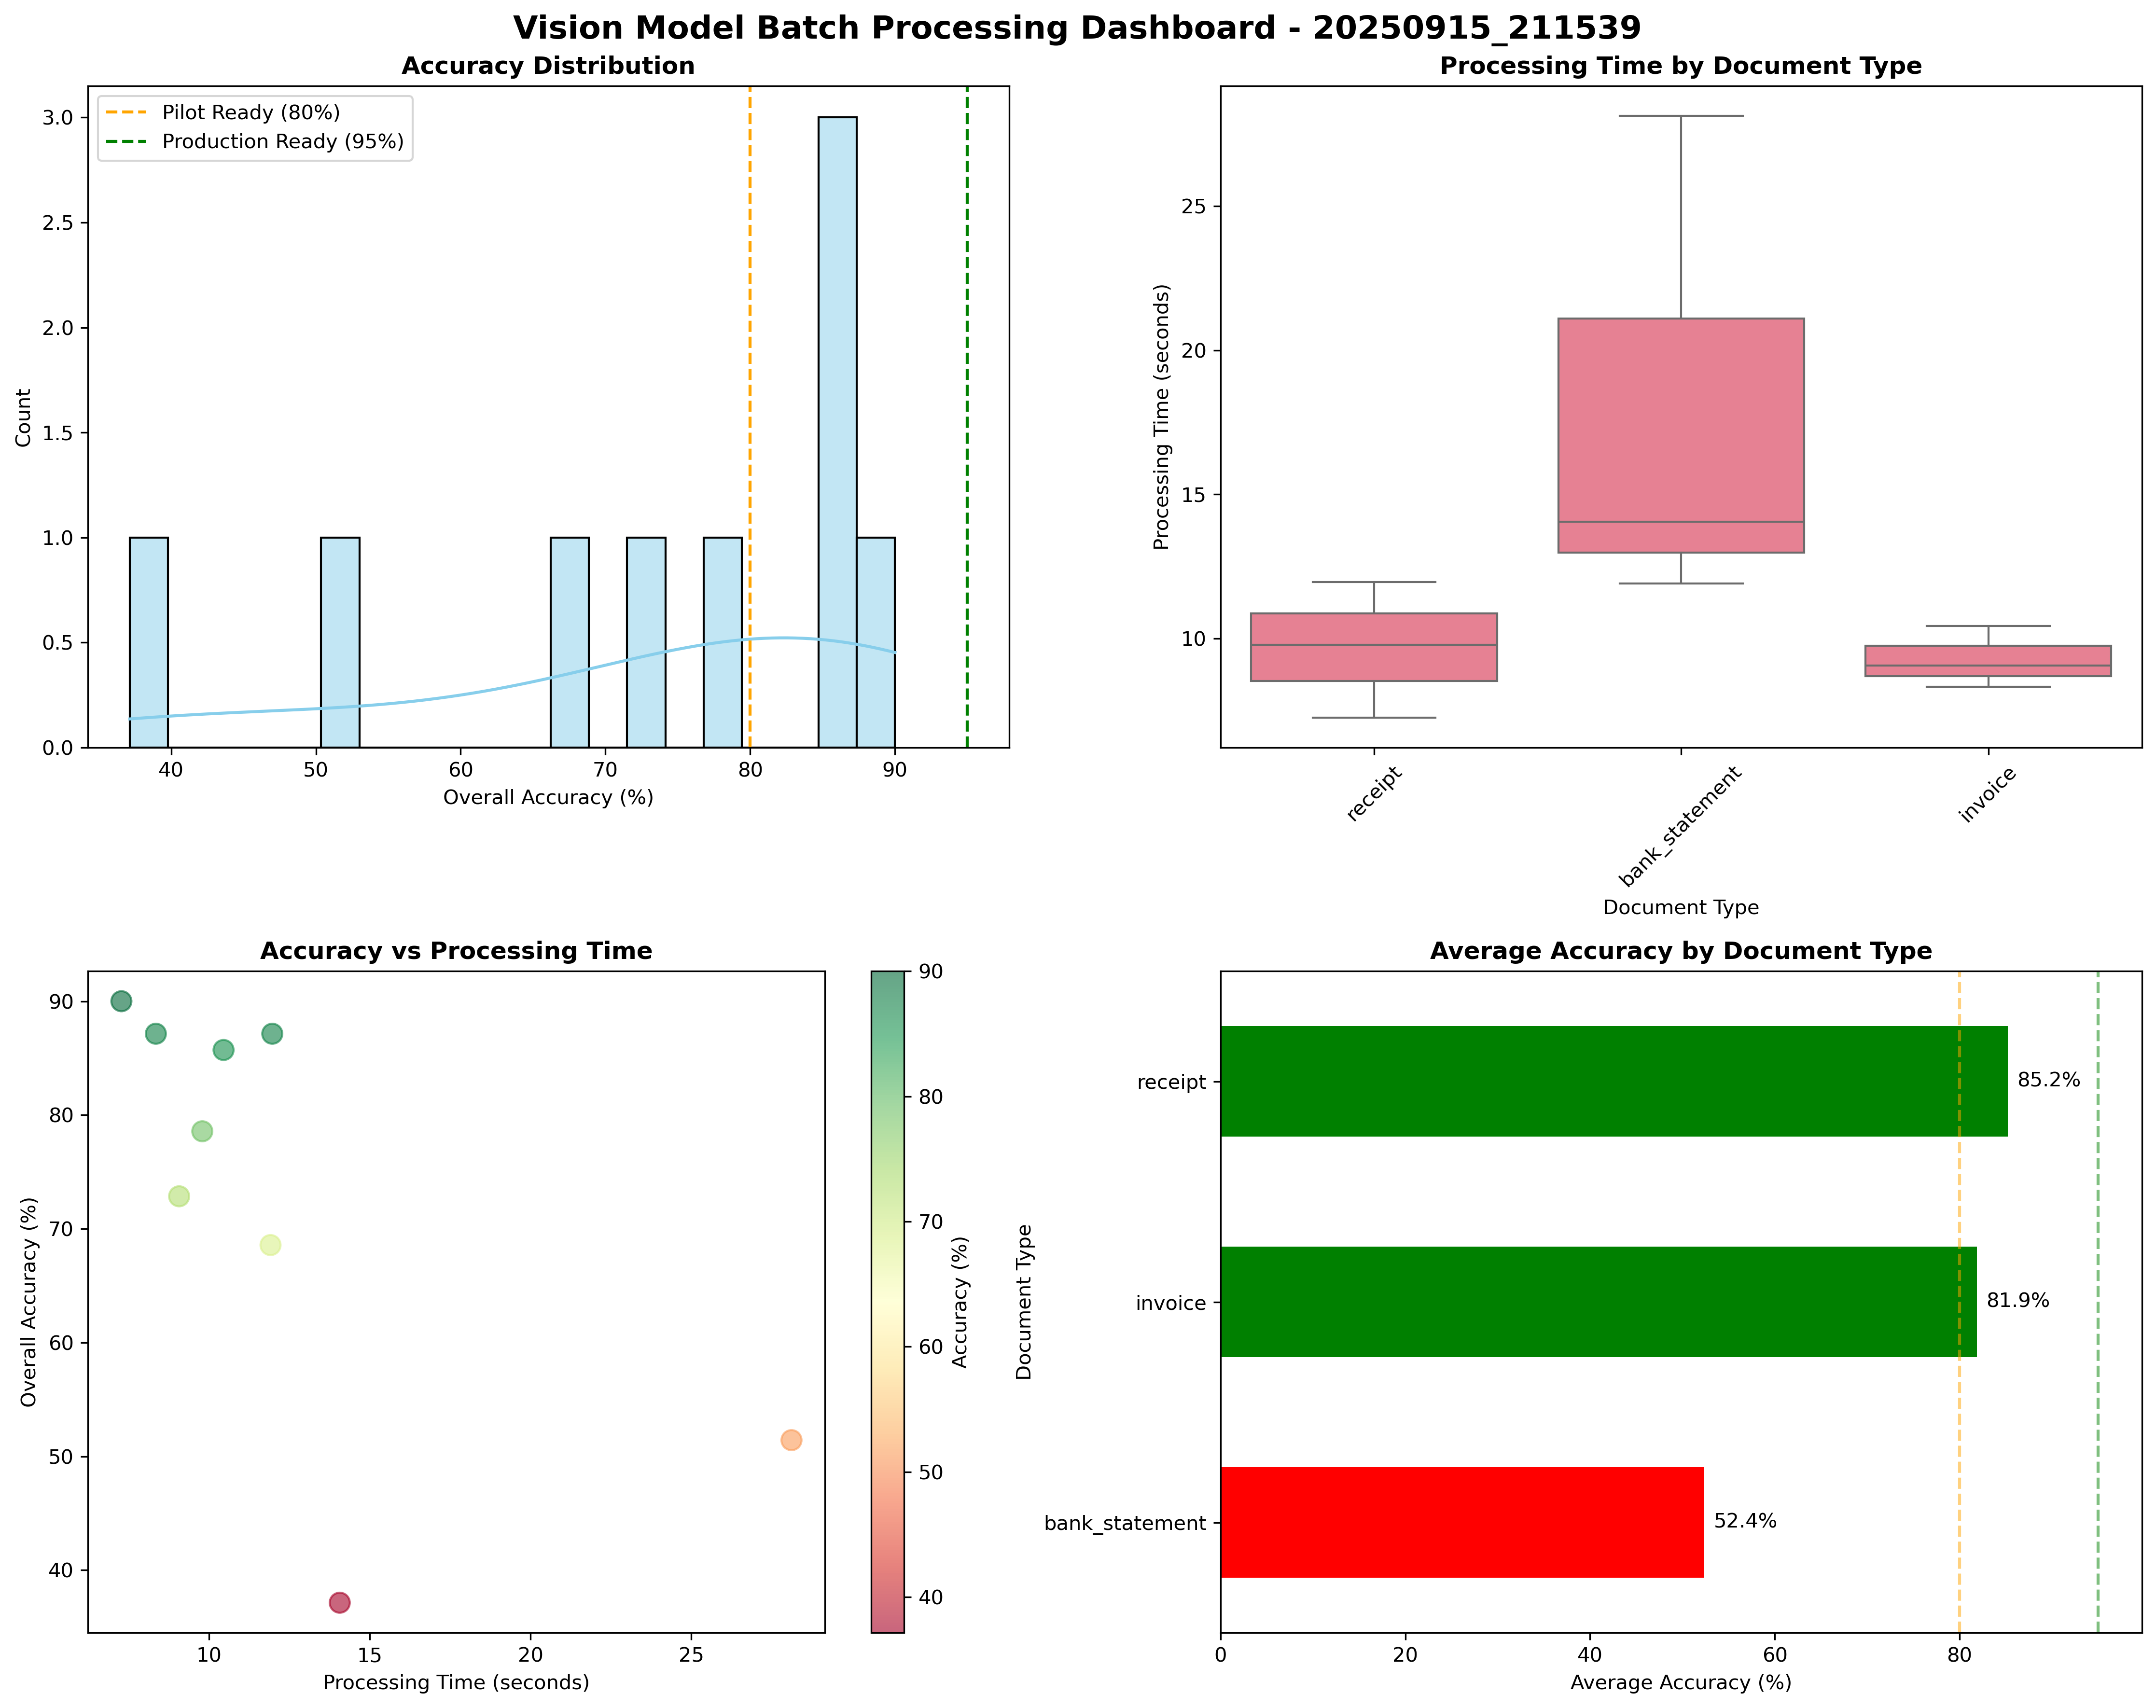

🎉 Clean InternVL3 batch processing complete!

In [12]:
# Display final summary
console.rule("[bold green]Batch Processing Complete[/bold green]")

total_images = len(batch_results)
successful = len([r for r in batch_results if 'error' not in r])
avg_accuracy = df_results['overall_accuracy'].mean() if len(df_results) > 0 else 0

rprint(f"[bold green]✅ Processed: {total_images} images[/bold green]")
rprint(f"[cyan]Success Rate: {(successful/total_images*100):.1f}%[/cyan]")
rprint(f"[cyan]Average Accuracy: {avg_accuracy:.2f}%[/cyan]")
if processing_times:
    rprint(f"[cyan]Average Time: {np.mean(processing_times):.2f}s[/cyan]")
rprint(f"[cyan]Output: {OUTPUT_BASE}[/cyan]")

# Display dashboard if available
dashboard_files = list(OUTPUT_DIRS['visualizations'].glob(f"dashboard_{BATCH_TIMESTAMP}.png"))
if dashboard_files:
    from IPython.display import Image, display
    dashboard_path = dashboard_files[0]
    rprint("\n[bold blue]📊 Visual Dashboard:[/bold blue]")
    display(Image(str(dashboard_path)))

rprint("\n[bold green]🎉 Clean InternVL3 batch processing complete![/bold green]")